In [1]:
from psrqpy.utils import get_glitch_catalogue
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    'font.size': 22,          # Base font size
    'axes.titlesize': 22,     # Title font size
    'axes.labelsize': 22,     # Axis label font size
    'xtick.labelsize': 22,    # X-axis tick font size
    'ytick.labelsize': 22,    # Y-axis tick font size
    'text.usetex': True,      # Enable external LaTeX requirement (ADDED COMMA)
    'mathtext.fontset': 'cm', # Use Computer Modern (TeX lookalike) for math (ADDED COMMA)
    'font.family': 'serif',   # Best practice: use serif family when using LaTeX
    'axes.linewidth': 1,      # (ADDED COMMA)
    'axes.grid': False,       # (ADDED COMMA)
    'axes.labelweight': 'normal'
})

glitches = get_glitch_catalogue()

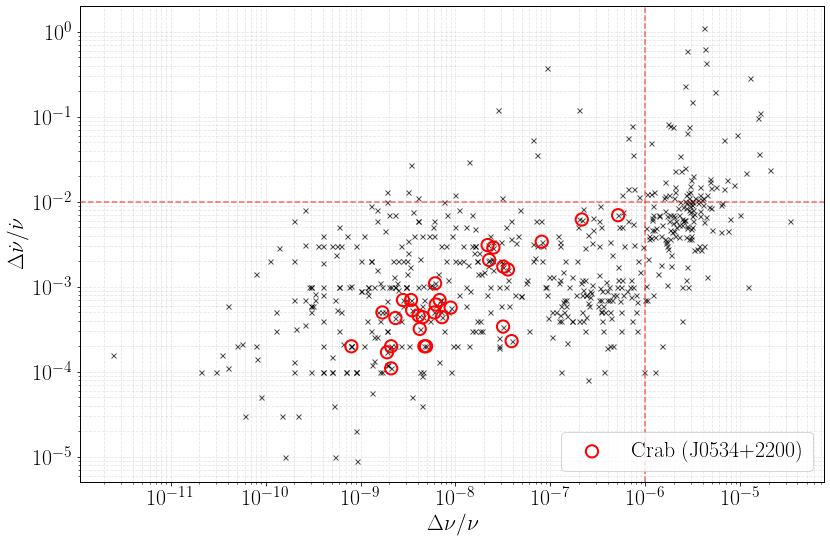

In [11]:
df = glitches.to_pandas()


plot_df = df.dropna(subset=['DeltaF/F', 'DeltaF1/F1']).copy()

# 2. Ensure columns are numeric to avoid plotting errors
cols = ['DeltaF/F', 'DeltaF/F_ERR', 'DeltaF1/F1', 'DeltaF1/F1_ERR']
for col in cols:
    plot_df[col] = pd.to_numeric(plot_df[col], errors='coerce')

# 3. Create the scatter plot
fig, ax = plt.subplots(figsize=(12, 8))

ax.errorbar(
    np.abs(plot_df['DeltaF/F']), 
    np.abs(plot_df['DeltaF1/F1']), 
    #xerr=plot_df['DeltaF/F_ERR'], 
    #yerr=plot_df['DeltaF1/F1_ERR'], 
    fmt='x', 
    color='k', 
    ecolor='k', 
    elinewidth=1, 
    capsize=2, 
    alpha=0.7,
    markersize=5
)

crab_df = plot_df[plot_df['JNAME'] == 'J0534+2200']

ax.scatter(
    np.abs(crab_df['DeltaF/F']),
    np.abs(crab_df['DeltaF1/F1']),
    facecolors='none',   # Transparent inside
    edgecolors='red',    # Red border
    s=150,               # Size of the circle (adjust as needed)
    linewidths=2,        # Thickness of the circle
    zorder=5,            # Forces the circles to be drawn on top of the teal dots
    label='Crab (J0534+2200)'
)

ax.axvline(x=1e-6, color='red', linestyle='--', alpha=0.6, zorder=4)
ax.axhline(y=1e-2, color='red', linestyle='--', alpha=0.6, zorder=4)

ax.legend(loc='lower right') # Added legend to show the Crab label

ax.set_xscale('log')
ax.set_yscale('log')

ax.set_xlabel(r'$\Delta \nu / \nu$')
ax.set_ylabel(r'$\Delta \dot{\nu} / \dot{\nu}$')

ax.grid(True, which='both', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.savefig('../plots/glitch_pop.png')
plt.show()

In [4]:
from psrqpy import QueryATNF

# 1. Download the Glitch Catalog
df_glitches = get_glitch_catalogue().to_pandas()

# 2. Download the F0 and F1 values from the main ATNF Catalog
# PSRJ = Pulsar Name, F0 = Frequency (Hz), F1 = Spin-down rate (Hz/s)
query = QueryATNF(params=['PSRJ', 'F0', 'F1'])
df_atnf = query.pandas

# Rename 'PSRJ' to 'JNAME' so it matches the glitch catalog's column name
df_atnf = df_atnf.rename(columns={'PSRJ': 'JNAME'})

# 3. Merge the two databases together!
# This looks at the JNAME in the glitch table and pulls the matching F0 from the ATNF table
df_merged = pd.merge(df_glitches, df_atnf, on='JNAME', how='left')

# Force the F0 and fractional jump columns to be numeric just in case
df_merged['F0'] = pd.to_numeric(df_merged['F0'], errors='coerce')
df_merged['DeltaF/F'] = pd.to_numeric(df_merged['DeltaF/F'], errors='coerce')

df_merged['F1'] = pd.to_numeric(df_merged['F1'], errors='coerce')
df_merged['DeltaF1/F1'] = pd.to_numeric(df_merged['DeltaF1/F1'], errors='coerce')


# 4. (Optional) Calculate the ABSOLUTE frequency jump (Delta F) in Hertz
df_merged['DeltaF'] = df_merged['DeltaF/F'] * df_merged['F0']

df_merged['DeltaF1'] = df_merged['DeltaF1/F1'] * df_merged['F1']

# Take a look at the results!
# print(df_merged[['JNAME', 'MJD', 'F0', 'DeltaF/F', 'DeltaF', 'F1', 'DeltaF1/F1', 'DeltaF1']].head())

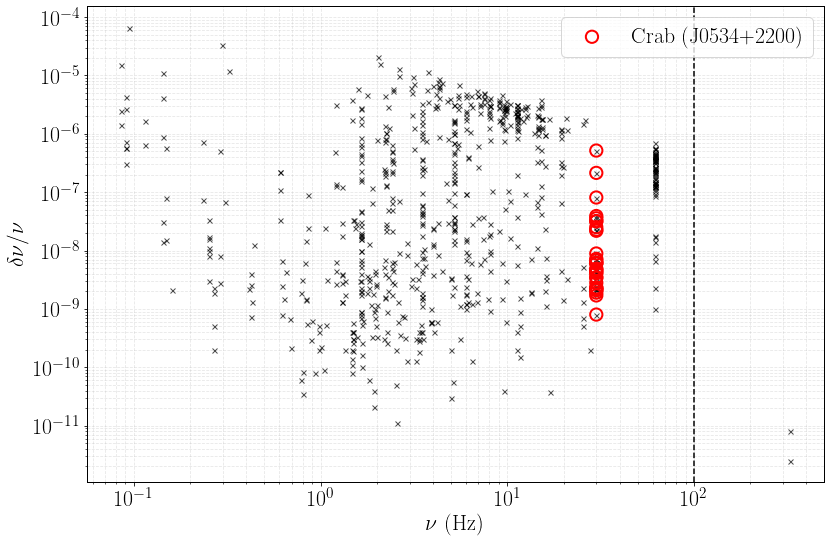

In [12]:

plot_df = df_merged.dropna(subset=['F0', 'DeltaF/F']).copy()

# 2. Ensure columns are numeric to avoid plotting errors
cols = ['F0', 'DeltaF/F']
for col in cols:
    plot_df[col] = pd.to_numeric(plot_df[col], errors='coerce')

# 3. Create the scatter plot
fig, ax = plt.subplots(figsize=(12, 8))

ax.errorbar(
    np.abs(plot_df['F0']), 
    np.abs(plot_df['DeltaF/F']), 
    # xerr=plot_df['DeltaF/F_ERR'], 
    # yerr=plot_df['DeltaF1/F1_ERR'], 
    fmt='x', 
    color='k', 
    ecolor='gray', 
    elinewidth=1, 
    capsize=2, 
    alpha=0.7,
    markersize=5
)



crab_df = plot_df[plot_df['JNAME'] == 'J0534+2200']


ax.scatter(
    np.abs(crab_df['F0']),
    np.abs(crab_df['DeltaF/F']),
    facecolors='none',   # Transparent inside
    edgecolors='red',    # Red border
    s=150,               # Size of the circle (adjust as needed)
    linewidths=2,        # Thickness of the circle
    zorder=5,            # Forces the circles to be drawn on top of the teal dots
    label='Crab (J0534+2200)'
)


ax.axvline(x=1e2, color='k', linestyle='--', alpha=1, zorder=4)



# Use log scales because pulsar glitches span many orders of magnitude
ax.set_xscale('log')
ax.set_yscale('log')

# Set labels
ax.set_xlabel(r'$\nu~\mathrm{(Hz)}$')
ax.set_ylabel(r'$\delta \nu/\nu$')
# ax.set_title(r'Pulsar Glitches: $\Delta F / F$ vs $|\Delta F_1 / F_1|$')
ax.legend(loc='upper right') # Added legend to show the Crab label

# Add a grid for easier reading
ax.grid(True, which='both', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.savefig('../plots/glitch_pop_nu.png')
plt.show()

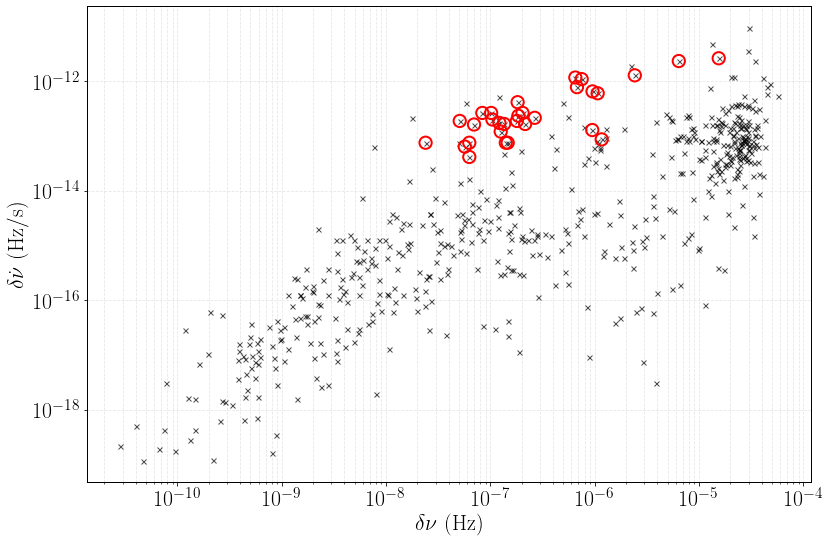

In [13]:

plot_df = df_merged.dropna(subset=['DeltaF', 'DeltaF1']).copy()

# 2. Ensure columns are numeric to avoid plotting errors
cols = ['DeltaF', 'DeltaF1']
for col in cols:
    plot_df[col] = pd.to_numeric(plot_df[col], errors='coerce')

# 3. Create the scatter plot
fig, ax = plt.subplots(figsize=(12, 8))

ax.errorbar(
    plot_df['DeltaF'], 
    np.abs(plot_df['DeltaF1']), 
    # xerr=plot_df['DeltaF/F_ERR'], 
    # yerr=plot_df['DeltaF1/F1_ERR'], 
    fmt='x', 
    color='k', 
    ecolor='gray', 
    elinewidth=1, 
    capsize=2, 
    alpha=0.7,
    markersize=5
)

crab_df = plot_df[plot_df['JNAME'] == 'J0534+2200']

ax.scatter(
    crab_df['DeltaF'],
    np.abs(crab_df['DeltaF1']),
    facecolors='none',   # Transparent inside
    edgecolors='red',    # Red border
    s=150,               # Size of the circle (adjust as needed)
    linewidths=2,        # Thickness of the circle
    zorder=5,            # Forces the circles to be drawn on top of the teal dots
    label='Crab (J0534+2200)'
)


# Use log scales because pulsar glitches span many orders of magnitude
ax.set_xscale('log')
ax.set_yscale('log')

# Set labels
ax.set_xlabel(r'$\delta \nu~\mathrm{(Hz)}$')
ax.set_ylabel(r'$\delta \dot{\nu}~\mathrm{(Hz/s)}$')
# ax.set_title(r'Pulsar Glitches: $\Delta F / F$ vs $|\Delta F_1 / F_1|$')

# Add a grid for easier reading
ax.grid(True, which='both', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()